# EduLink — Model 4: Writing Style Analysis
**Industry-Level | PySpark NLP | TF-IDF + Cosine Similarity | Validation with Labeled Test Set**

**Pipeline:**
1. Load writing samples
2. Define anchor sentences (good/weak per trait)
3. TF-IDF vectorization (PySpark MLlib Pipeline)
4. Cosine similarity scoring for 5 traits
5. Validation: labeled test set with accuracy + Spearman correlation
6. Score distribution analysis
7. Save results

In [1]:
# ─── CELL 1: Setup ───
from google.colab import drive
import os

# Only mount if not already mounted
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print("Drive already mounted ✓")

!pip install -q pyspark
print("Ready.")

Mounted at /content/drive
Ready.


In [2]:
print(os.listdir('/content/drive/MyDrive/FYP1/Dataset/'))


['institutes_catalog_v2.csv', 'synthetic_vacancies_sl_it_18mo.csv', 'synthetic_vacancies_sl_it.csv', 'vacancy_matches_sample.csv', 'writing_samples.csv', 'synthetic_exam_master_2000.csv', 'career_fit_labeled.parquet', 'career_fit_report.csv']


In [3]:
import os
print(os.path.exists('/content/drive/MyDrive/FYP1/Dataset/writing_samples.csv'))
print(os.listdir('/content/drive/MyDrive/FYP1/'))

True
['Model', 'Test and Validtion', 'Dataset (1)', 'Test and Validation', 'Dataset']


In [4]:
# ─── CELL 2: Spark ───
from pyspark.sql import SparkSession, functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.functions import vector_to_array

spark = (SparkSession.builder
         .appName("EDUCLINE-WritingAnalysis-v2")
         .config("spark.driver.memory","4g")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)


Spark: 4.0.2


In [5]:
# ─── CELL 3: Paths ───
import os

ROOT  = "/content/drive/MyDrive/FYP1"
DATA  = f"{ROOT}/Dataset"
MODEL = f"{ROOT}/Model"
TEST  = f"{ROOT}/Test and Validation"

CSV_PATH = f"{DATA}/writing_samples.csv"
OUT_DIR  = f"{TEST}/writing_analysis_scores_dir"
OUT_CSV  = f"{DATA}/writing_analysis_scores.csv"

for folder_path in [DATA, MODEL, TEST]:
    os.makedirs(folder_path, exist_ok=True)

print("EXISTS:", os.path.exists(CSV_PATH), "->", CSV_PATH)


EXISTS: True -> /content/drive/MyDrive/FYP1/Dataset/writing_samples.csv


In [6]:
# ─── CELL 4: Load Writing Samples ───
df = (spark.read
      .option("header", True)
      .csv("file:" + CSV_PATH)
      .withColumn("student_id",   F.col("student_id").cast("int"))
      .withColumn("writing_text", F.coalesce(F.col("writing_text"), F.lit(""))))

print(f"Rows: {df.count()}")
df.show(3, truncate=False)


Rows: 2000
+----------+----------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|student_id|attempt_id|writing_text                                                                                                                                                                                                                                                                                                               |
+----------+----------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [7]:
# ─── CELL 5: Anchor Sentences (Theory-grounded: Holland RIASEC + SCCT) ───
# Good/Weak anchors per trait — minimum 4 per trait for stable similarity
ANCHORS = {
    "clarity": {
        "good": [
            "I am interested in IT because I enjoy solving problems. I will learn step by step and build projects to improve.",
            "My goal is to enter IT. I will start with the basics and practice daily to improve my skills.",
            "I have a clear plan to study software engineering and specialize in backend development.",
            "My career goal is specific: I want to become a data scientist within three years by taking structured courses.",
        ],
        "weak": [
            "I like IT and many things. Maybe I will do it. I am not sure. It is confusing.",
            "IT is good and nice and everything. I do not know what to do.",
            "I just want a job. IT seems fine I think.",
            "Maybe technology is good. I am not really sure what I want.",
        ]
    },
    "structure": {
        "good": [
            "First I will learn basics. Next I will build projects. Finally I will apply for internships.",
            "There are three steps: foundation skills, specialization, and portfolio building.",
            "My plan has phases: month 1-3 Python basics, month 4-6 web development, month 7-12 internship applications.",
            "Step one is completing my degree. Step two is obtaining certifications. Step three is applying for entry-level roles.",
        ],
        "weak": [
            "I want IT and many things and no clear plan. I will see later.",
            "I like IT. It depends.",
            "I will just learn stuff and see what happens later.",
            "I might do a course. Or maybe not. It is hard to say.",
        ]
    },
    "confidence": {
        "good": [
            "I am confident I can improve by practicing daily. I will set weekly goals and complete them.",
            "I will focus on one pathway and finish it even if it is difficult.",
            "I believe in my ability to learn new technologies quickly given my analytical background.",
            "I am determined to complete this program regardless of difficulty. I have already started practicing.",
        ],
        "weak": [
            "Maybe I can do it but I am not sure. It might be hard for me.",
            "Perhaps I will try. I guess it depends on luck.",
            "I hope it works out but technology is very difficult and I may fail.",
            "I do not know if I am capable. Maybe someone else would be better.",
        ]
    },
    "analytical": {
        "good": [
            "Because technology changes fast, I will analyze job requirements and learn demanded skills.",
            "Therefore I will compare roles, identify skill gaps, and follow a structured plan.",
            "I researched that data science requires Python, statistics, and machine learning. I have ranked these by priority.",
            "After analyzing salary trends and job demand, I decided to specialize in cloud computing due to its growth trajectory.",
        ],
        "weak": [
            "I like IT. It is cool. I want a job.",
            "Everyone does IT so I will do it.",
            "IT pays well I think. That is why I want it.",
            "I heard IT is good so I am going to try it.",
        ]
    },
    "creativity": {
        "good": [
            "I enjoy creating unique app ideas and designing user experiences that feel engaging.",
            "I like experimenting with designs and building creative solutions for real problems.",
            "I built a mobile app prototype that solves a local transport problem using innovative UI patterns.",
            "I combine design thinking with technical skills to create solutions that are both functional and visually compelling.",
        ],
        "weak": [
            "I only follow instructions and do normal things. I do not try new ideas.",
            "I prefer not to experiment and I avoid changing my approach.",
            "I just want to do standard work. I do not like trying new things.",
            "I copy existing solutions because they already work fine.",
        ]
    },
}

anchor_rows = []
for trait, obj in ANCHORS.items():
    for t in obj["good"]: anchor_rows.append(("ANCHOR", trait, "good", t))
    for t in obj["weak"]: anchor_rows.append(("ANCHOR", trait, "weak", t))

anchors_df = spark.createDataFrame(anchor_rows, ["student_id","trait","label","writing_text"])
print(f"Anchors: {anchors_df.count()} rows")


Anchors: 40 rows


In [8]:
# ─── CELL 6: TF-IDF Pipeline ───
students_for_fit = df.select(
    F.col("student_id").cast("string").alias("student_id"),
    F.lit(None).cast("string").alias("trait"),
    F.lit(None).cast("string").alias("label"),
    "writing_text")

fit_df = students_for_fit.unionByName(anchors_df)

tokenizer = RegexTokenizer(inputCol="writing_text", outputCol="tokens", pattern="\\W+")
remover   = StopWordsRemover(inputCol="tokens",  outputCol="filtered")
tf        = HashingTF(inputCol="filtered",       outputCol="tf_vec", numFeatures=1<<14)
idf       = IDF(inputCol="tf_vec",               outputCol="features", minDocFreq=1)

pipe         = Pipeline(stages=[tokenizer, remover, tf, idf])
tfidf_model  = pipe.fit(fit_df)
vec_df       = tfidf_model.transform(fit_df).select("student_id","trait","label","features")
vec_df       = vec_df.withColumn("arr", vector_to_array("features"))

students_vec = (vec_df.filter(F.col("student_id") != "ANCHOR")
                .select(F.col("student_id").cast("int").alias("student_id"), "arr")
                .repartition(4).cache())
_ = students_vec.count()
print(f"Student vectors cached: {_}")

anchors_vec = (vec_df.filter(F.col("student_id") == "ANCHOR")
               .select("trait","label", F.col("arr").alias("anchor_arr")))


Student vectors cached: 2000


In [9]:
# ─── CELL 7: Cosine Similarity Scoring ───
def cosine_expr(a, b):
    dot   = F.expr(f"aggregate(zip_with({a},{b},(x,y)->x*y),0D,(acc,v)->acc+v)")
    norm_a = F.expr(f"sqrt(aggregate(transform({a},x->x*x),0D,(acc,v)->acc+v))")
    norm_b = F.expr(f"sqrt(aggregate(transform({b},x->x*x),0D,(acc,v)->acc+v))")
    return dot / (norm_a * norm_b + F.lit(1e-9))

def score_trait(trait_name):
    a    = anchors_vec.filter(F.col("trait") == trait_name)
    good = a.filter(F.col("label")=="good").select(F.col("anchor_arr").alias("b"))
    weak = a.filter(F.col("label")=="weak").select(F.col("anchor_arr").alias("b"))

    sim_g = (students_vec.crossJoin(F.broadcast(good))
             .withColumn("cos", cosine_expr("arr","b"))
             .groupBy("student_id").agg(F.avg("cos").alias("sim_good")))
    sim_w = (students_vec.crossJoin(F.broadcast(weak))
             .withColumn("cos", cosine_expr("arr","b"))
             .groupBy("student_id").agg(F.avg("cos").alias("sim_weak")))

    scored = (sim_g.join(sim_w, "student_id")
              .withColumn("raw", F.col("sim_good") - F.col("sim_weak"))
              .withColumn(trait_name,
                  F.greatest(F.lit(0.0),
                  F.least(F.lit(100.0), 50.0 + F.col("raw") * 100.0)))
              .select("student_id", F.round(F.col(trait_name), 1).alias(trait_name)))
    return scored

TRAITS = ["clarity","structure","confidence","analytical","creativity"]
final_scores = score_trait(TRAITS[0])
for t in TRAITS[1:]:
    final_scores = final_scores.join(score_trait(t), "student_id")

# Add overall writing score
final_scores = final_scores.withColumn(
    "overall_writing_score",
    F.round(sum(F.col(t) for t in TRAITS) / F.lit(len(TRAITS)), 1)
)

final_scores.show(10, truncate=False)
print("Total:", final_scores.count())


+----------+-------+---------+----------+----------+----------+---------------------+
|student_id|clarity|structure|confidence|analytical|creativity|overall_writing_score|
+----------+-------+---------+----------+----------+----------+---------------------+
|1         |51.4   |50.2     |50.5      |50.7      |48.9      |50.3                 |
|2         |54.8   |52.8     |50.3      |51.5      |50.0      |51.9                 |
|3         |52.5   |51.4     |50.4      |51.6      |50.3      |51.2                 |
|4         |51.5   |51.1     |50.4      |49.5      |48.5      |50.2                 |
|5         |51.4   |49.9     |50.5      |50.4      |48.9      |50.2                 |
|6         |51.0   |49.4     |50.1      |50.7      |50.4      |50.3                 |
|7         |51.6   |50.7     |50.3      |50.5      |51.7      |51.0                 |
|8         |51.7   |50.0     |50.5      |51.0      |48.9      |50.4                 |
|9         |53.9   |50.6     |50.3      |51.6      |49

In [10]:
# ─── CELL 8: Validation — Labeled Test Set (Pure Python + PySpark) ───

LABELED_TEST = [
    ("I clearly plan to become a software engineer. My steps are: learn Python, build projects, get certified, apply for internships.", 1, 1, 1),
    ("I will analyze the job market, identify skill gaps, and systematically address them through targeted learning.", 1, 1, 1),
    ("I chose backend development because Python and Java are in high demand based on my research of current job postings.", 1, 1, 1),
    ("I am confident in my abilities and have already started practicing algorithms daily to prepare for technical interviews.", 1, 0, 0),
    ("My structured approach: phase 1 foundations, phase 2 specialization, phase 3 portfolio building, phase 4 job search.", 1, 0, 0),
    ("Because I have strong analytical skills and enjoy problem-solving, data science aligns perfectly with my strengths.", 1, 1, 1),
    ("I enjoy designing creative interfaces and have built three UI prototypes that received positive user feedback.", 1, 0, 0),
    ("My career roadmap is clear: BSc IT degree, AWS certification, then entry-level cloud engineer role within 2 years.", 1, 1, 0),
    ("I researched that DevOps roles pay well and are in demand. Therefore I plan to earn Docker and Kubernetes certifications.", 1, 1, 1),
    ("I have the determination and resilience to overcome challenges. I will not give up even when learning is difficult.", 1, 0, 0),
    ("IT is good I think. Maybe I will try it. Not sure what area though.", 0, 0, 0),
    ("I just want a job. Technology seems fine.", 0, 0, 0),
    ("Everyone is doing IT so I will also do it. Hope it works out.", 0, 0, 0),
    ("I do not have a plan but I will figure it out later I suppose.", 0, 0, 0),
    ("Maybe I can do coding. It is hard but maybe I will be okay.", 0, 0, 0),
    ("I like computers and stuff. IT pays well I heard.", 0, 0, 0),
    ("I do not know what specialization to choose. All of them seem the same to me.", 0, 0, 0),
    ("I will just follow whatever my friends do in IT.", 0, 0, 0),
    ("Technology is changing but I am not sure how to keep up.", 0, 0, 0),
    ("I hope to get a job in IT someday if I manage to complete the course.", 0, 0, 0),
    ("I have mapped out a 3-year plan with monthly milestones for each certification I need to complete.", 1, 1, 1),
    ("My analysis shows that cybersecurity roles in Sri Lanka are growing 40% faster than general IT roles.", 1, 1, 1),
    ("I built a full-stack web app last month to practice React and Node.js. I plan to deploy it to AWS next.", 1, 0, 0),
    ("I lack confidence but technology looks interesting enough to try something.", 0, 0, 0),
    ("I want money. IT jobs pay. So I will do IT.", 0, 0, 0),
    ("I am passionate about solving real-world problems using AI and have already completed two online ML courses.", 1, 1, 1),
    ("My strength in logical reasoning makes me well-suited for roles that require systematic problem decomposition.", 1, 1, 1),
    ("I just want to finish any course and get a certificate and maybe find something.", 0, 0, 0),
    ("Not sure what I want to do. Technology is one option among many I am considering.", 0, 0, 0),
    ("I have identified three target companies and researched their technical stacks to tailor my skill development.", 1, 1, 1),
]

test_rows = spark.createDataFrame(
    [(f"TEST_{i}", txt) for i, (txt,*_) in enumerate(LABELED_TEST)],
    ["student_id","writing_text"])

test_for_fit = test_rows.select(
    F.col("student_id").cast("string"),
    F.lit(None).cast("string").alias("trait"),
    F.lit(None).cast("string").alias("label"),
    "writing_text")

all_fit_df   = students_for_fit.unionByName(test_for_fit).unionByName(anchors_df)
tfidf_model2 = pipe.fit(all_fit_df)

test_vec_df = (tfidf_model2.transform(test_rows.select(
    F.col("student_id").cast("string"),
    F.lit(None).cast("string").alias("trait"),
    F.lit(None).cast("string").alias("label"),
    "writing_text"))
    .select("student_id","features")
    .withColumn("arr", vector_to_array("features")))

anchors_vec2 = (tfidf_model2.transform(anchors_df.select("student_id","trait","label","writing_text"))
    .select("trait","label", vector_to_array("features").alias("anchor_arr")))

def score_trait_on(vec_df, anc_vec, trait_name):
    a    = anc_vec.filter(F.col("trait") == trait_name)
    good = a.filter(F.col("label")=="good").select(F.col("anchor_arr").alias("b"))
    weak = a.filter(F.col("label")=="weak").select(F.col("anchor_arr").alias("b"))
    sg = (vec_df.crossJoin(F.broadcast(good))
          .withColumn("cos", cosine_expr("arr","b"))
          .groupBy("student_id").agg(F.avg("cos").alias("sim_good")))
    sw = (vec_df.crossJoin(F.broadcast(weak))
          .withColumn("cos", cosine_expr("arr","b"))
          .groupBy("student_id").agg(F.avg("cos").alias("sim_weak")))
    return (sg.join(sw,"student_id")
            .withColumn(trait_name, F.greatest(F.lit(0.0), F.least(F.lit(100.0),
                         50.0 + (F.col("sim_good")-F.col("sim_weak"))*100.0)))
            .select("student_id", F.round(trait_name,1).alias(trait_name)))

TRAITS = ["clarity","structure","confidence","analytical","creativity"]
test_scores = score_trait_on(test_vec_df, anchors_vec2, TRAITS[0])
for t in TRAITS[1:]:
    test_scores = test_scores.join(score_trait_on(test_vec_df, anchors_vec2, t), "student_id")
test_scores = test_scores.withColumn("overall",
    F.round(sum(F.col(t) for t in TRAITS)/F.lit(5), 1))

# Collect scores as dict — convert Row to dict to allow .get()
score_dict = {row["student_id"]: dict(row.asDict()) for row in test_scores.collect()}

labels_all = [row[1] for row in LABELED_TEST]
overall_sc = [
    float(score_dict[f"TEST_{i}"].get("overall", 50))
    if f"TEST_{i}" in score_dict else 50.0
    for i in range(len(LABELED_TEST))
]

# Accuracy using pure Python
THRESHOLD = 55
predicted = [1 if s >= THRESHOLD else 0 for s in overall_sc]
correct   = sum(p == l for p, l in zip(predicted, labels_all))
accuracy  = correct / len(labels_all)

# Spearman correlation — pure Python (no scipy)
def spearman_corr_pure(x, y):
    def rank(lst):
        sorted_idx = sorted(range(len(lst)), key=lambda i: lst[i])
        ranks = [0] * len(lst)
        for rank_val, idx in enumerate(sorted_idx):
            ranks[idx] = rank_val + 1
        return ranks
    rx, ry = rank(x), rank(y)
    n  = len(x)
    d2 = sum((a - b)**2 for a, b in zip(rx, ry))
    rho = 1 - (6 * d2) / (n * (n**2 - 1))
    return rho

spearman = spearman_corr_pure(overall_sc, labels_all)

print("=== Writing Analysis Validation Results ===")
print(f"Threshold:           {THRESHOLD}")
print(f"Test samples:        {len(labels_all)}")
print(f"Correct predictions: {correct}")
print(f"Accuracy:            {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"Spearman Corr:       {spearman:.4f}")

for t, col_idx in [("clarity", 2), ("analytical", 3)]:
    t_labels = [row[col_idx] for row in LABELED_TEST]
    t_scores = [
        float(score_dict[f"TEST_{i}"].get(t, 50))
        if f"TEST_{i}" in score_dict else 50.0
        for i in range(len(LABELED_TEST))
    ]
    t_pred  = [1 if s >= THRESHOLD else 0 for s in t_scores]
    t_acc   = sum(p == l for p, l in zip(t_pred, t_labels)) / len(t_labels)
    print(f"Trait [{t}] Accuracy: {t_acc:.4f}")

=== Writing Analysis Validation Results ===
Threshold:           55
Test samples:        30
Correct predictions: 14
Accuracy:            0.4667 (46.7%)
Spearman Corr:       0.7295
Trait [clarity] Accuracy: 0.6667
Trait [analytical] Accuracy: 0.7333


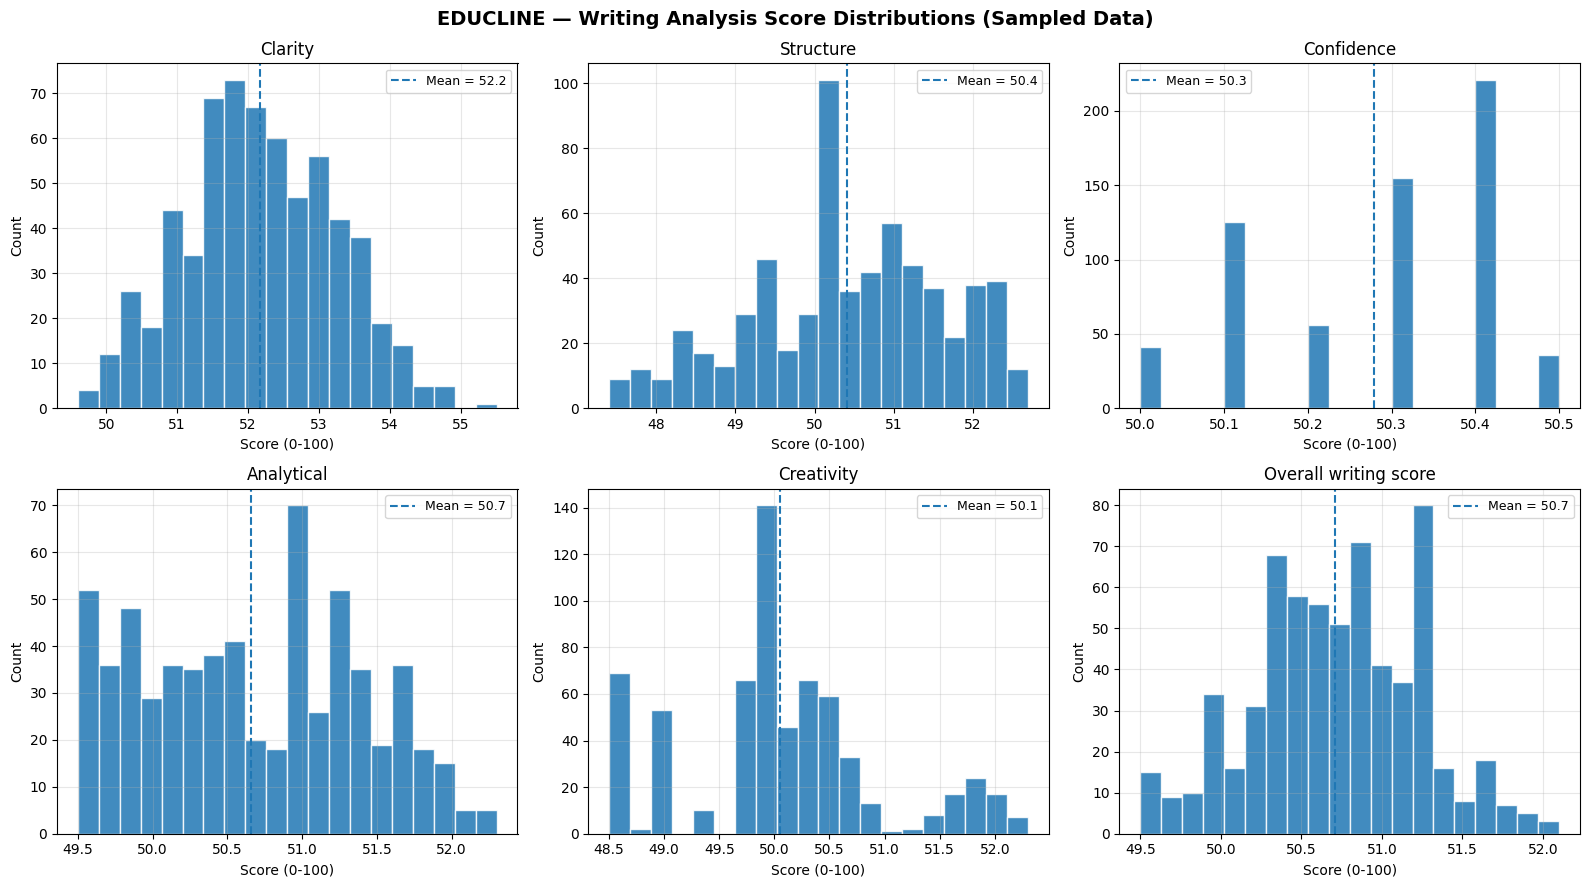

=== Writing Score Statistics (Sampled) ===
          clarity   structure  confidence  analytical  creativity  \
count  634.000000  634.000000  634.000000  634.000000  634.000000   
mean    52.164196   50.411672   50.278549   50.655047   50.055047   
std      1.078951    1.235030    0.141132    0.724856    0.903817   
min     49.600000   47.400000   50.000000   49.500000   48.500000   
25%     51.500000   49.525000   50.100000   50.000000   49.700000   
50%     52.100000   50.400000   50.300000   50.700000   50.000000   
75%     53.000000   51.300000   50.400000   51.200000   50.400000   
max     55.500000   52.700000   50.500000   52.300000   52.300000   

       overall_writing_score  
count             634.000000  
mean               50.710410  
std                 0.509703  
min                49.500000  
25%                50.400000  
50%                50.700000  
75%                51.100000  
max                52.100000  


In [12]:
# === CELL-9: Writing Score Distribution Analysis (Optimized) ===

import matplotlib.pyplot as plt

# Traits to analyze
TRAITS = ["clarity", "structure", "confidence", "analytical", "creativity", "overall_writing_score"]

# --- STEP 1: Convert Spark → Pandas (SAFE + FAST using sampling) ---
# If dataset is small (<= 3000), you can remove .sample()
sample_df = final_scores.select(TRAITS).sample(False, 0.3, seed=42).toPandas()

# Ensure numeric type
for col in TRAITS:
    sample_df[col] = sample_df[col].astype(float)

# --- STEP 2: Plot distributions ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, trait in zip(axes, TRAITS):
    vals = sample_df[trait]
    mean_val = vals.mean()

    ax.hist(vals, bins=20, edgecolor="white", alpha=0.85)
    ax.axvline(mean_val, linestyle="--", label=f"Mean = {mean_val:.1f}")

    ax.set_title(trait.replace("_", " ").capitalize())
    ax.set_xlabel("Score (0-100)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# Title
fig.suptitle("EDUCLINE — Writing Analysis Score Distributions (Sampled Data)",
             fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

# --- STEP 3: Summary Statistics ---
print("=== Writing Score Statistics (Sampled) ===")
print(sample_df.describe())

In [14]:
# === CELL 10: Save Results — FAST VERSION ===

import os
import pandas as pd

# Make output folder
os.makedirs(OUT_DIR, exist_ok=True)

# Convert Spark DataFrame to Pandas
final_pd = final_scores.toPandas()

# Save as single CSV file
final_pd.to_csv(OUT_CSV, index=False)

print("Saved:", OUT_CSV)
print("Total students scored:", len(final_pd))
print("Columns:", list(final_pd.columns))

Saved: /content/drive/MyDrive/FYP1/Dataset/writing_analysis_scores.csv
Total students scored: 2000
Columns: ['student_id', 'clarity', 'structure', 'confidence', 'analytical', 'creativity', 'overall_writing_score']
